
# DPO — Preference Alignment
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

> *A hands-on walkthrough of the three preference-alignment techniques that shaped LLM training: **SFT → DPO → ORPO**, applied to an Arabic instruction-tuning task.*


##  What's in this notebook

| Section | What you'll do |
|---|---|
| 1. The motivation | Why prompts aren't enough — and what alignment actually changes |
| 2. PPO vs DPO vs ORPO | The three algorithms, with architecture diagrams for each |
| 3. Setup | Unsloth + TRL  install in 4-bit, load Qwen2.5-3B with LoRA |
| 4. SFT pass | Teach the model Arabic instruction-following on **Bactrian-X** |
| 5. DPO pass | Align with **FreedomIntelligence/Arabic-preference-data-RLHF** |
| 6. ORPO pass | Single-stage alternative — half the compute, same quality |
| 7. Picking your method | Decision flow + comparison infographic |
| 8. **Before vs After DPO** | Side-by-side comparison on real Arabic prompts |
| 9. Recap & further reading | What we covered + 2025–2026 alignment papers |


## 1.  The motivation

Ever been chatting with ChatGPT (or any chat agent) and had two answers pop up asking you to pick the better one?

![texte](https://us1.discourse-cdn.com/openai1/original/4X/d/5/4/d54fe3d0604083f75b67dae18945a68134313c9c.png)

If you clicked one, congratulations — you officially took part in the preference alignment optimization of ChatGPT.

This is the heart of **preference alignment (PA)**, one of the biggest shifts in LLM training over the last four years. Instead of relying only on proxy datasets, PA uses real human feedback to teach the model what's actually preferred in the environment it lives in.

### But why not just use a prompt?

A prompt is an instruction the model reads and tries to follow. The model underneath was trained on the whole internet — including plenty of toxic and biased content — and a prompt is asking it to override what it already learned. That works for easy cases, not hard ones:

- **Prompts get ignored or overridden.** Long conversations weaken the model's attention to them. Users can paste contradicting instructions. Jailbreaks (*"ignore previous instructions…"*) exist precisely because prompts are *requests*, not constraints baked into the weights.
- **Prompts can't fix bad defaults.** Saying *"be careful with medical advice"* suppresses overconfidence; alignment changes the instinct itself.
- **Prompts can't teach judgment.** *"Be thoughtful, humble, know when to push back"* is thousands of subtle calls. Alignment learns the pattern from examples; a prompt only sketches it.
- **Prompts can leak or be removed.** If the prompt is the only safety layer, losing it loses safety. Aligned behavior travels with the weights.
- **Prompts cost tokens.** Every request pays for them in latency, context, and money. Alignment moves that work into the weights — free at inference time.
- **Prompts can't resolve trade-offs.** *"Helpful but harmless"* 

**In short: alignment changes what the model *wants* to do; prompts change what it's *asked* to do.** They work together, but relying on prompts alone is building on sand.


## 2.  PPO vs DPO vs ORPO — the architectures

> **A heads-up before we start.** This notebook gets into reinforcement learning territory. Yes, the same family of algorithms that teaches robots to walk. If RL is new to you, the vocabulary might feel heavy at first (policies, rewards, KL divergence…), but the underlying idea is genuinely simple: **show the model good and bad examples, and nudge it toward the good ones.** That's it. Everything else is engineering around that one idea.

All three algorithms answer the same question:

> *Given a base model and pairs of (chosen answer, rejected answer), how do we update the model so it prefers the chosen one — without breaking everything else it knows?*

They differ in **how** they get there.


### 2.1 PPO — the original recipe (3 moving parts)

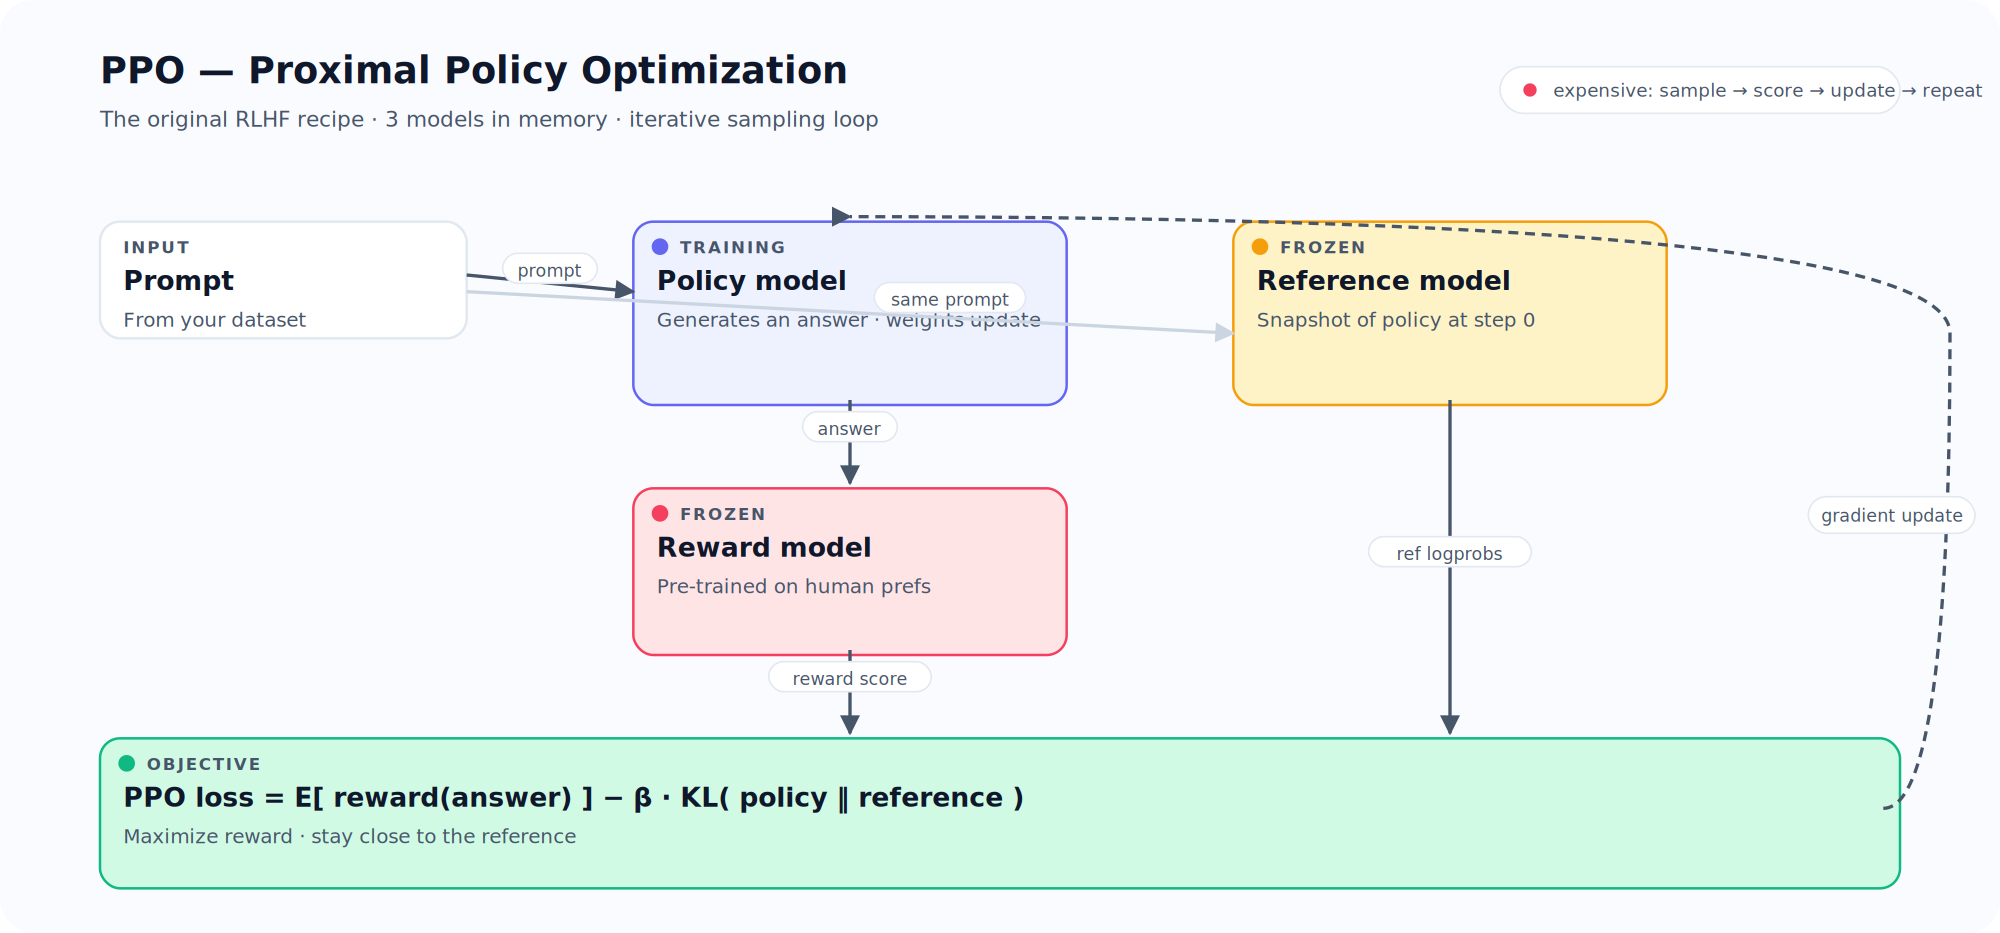


**Three models live in memory together:**

| Model | Role | Trained? |
|---|---|---|
| **Policy** | Generates answers; this is what you're aligning |  Yes |
| **Reward model** | Scores answers using a network pre-trained on human preference data |  Frozen |
| **Reference model** | Frozen copy of the starting policy; used to penalize drift via KL |  Frozen |

**The training loop:**
1. Take a prompt
2. **Policy** generates an answer
3. **Reward model** scores that answer
4. **Reference model** computes the KL penalty
5. Update the policy: maximize reward, but stay close to the reference
6. Repeat

The KL penalty is the safety belt. Without it, the policy would happily exploit any quirk of the reward model and produce gibberish that scores high but reads terribly. The reference model is the anchor that says *"don't go too far from where you started."*

Powerful, but expensive: **three models in GPU memory, generation happens *during* training (slow), and the reward model itself had to be trained earlier on a separate human-preference dataset.** A real engineering pipeline.


### 2.2 DPO — the elegant shortcut (2 moving parts)

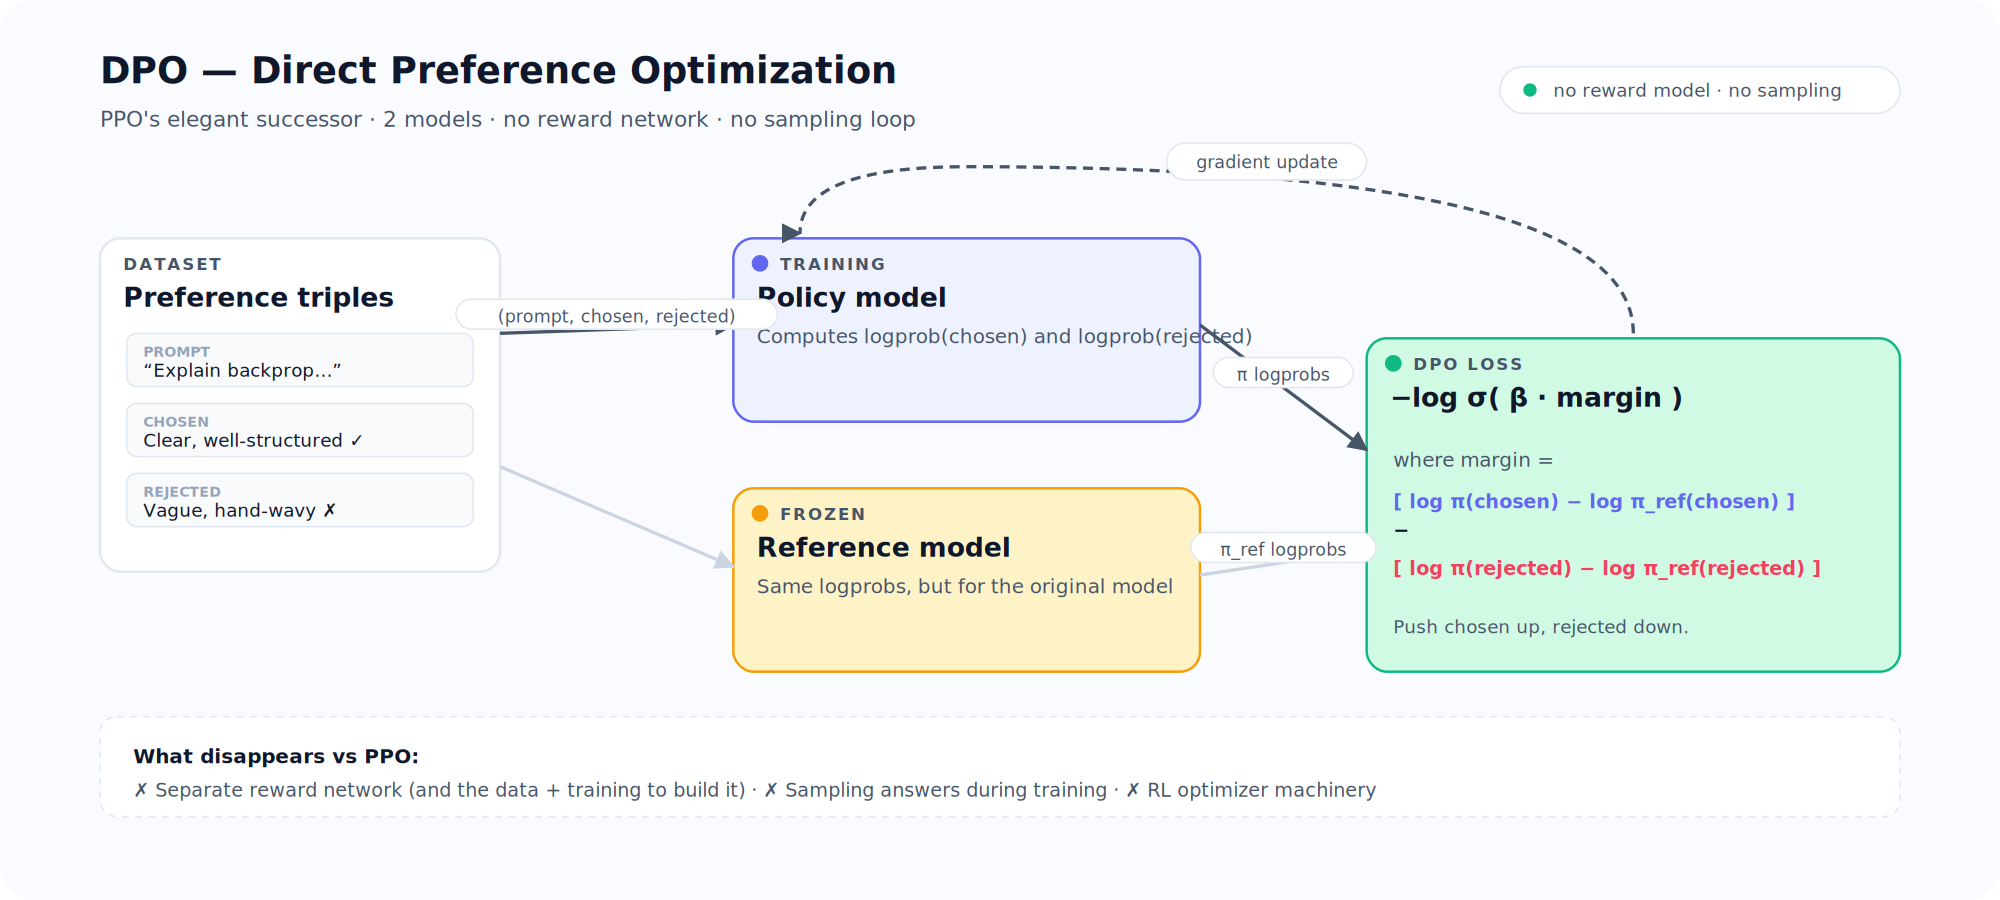


**DPO's key insight:** you don't need a separate reward model. The math works out so that you can express the optimal reward directly as a *log-probability ratio* between the policy and the reference model. No reward model. No sampling loop. No RL machinery.

You just need:
- The **policy** (the model you're training)
- The **reference model** (frozen copy of the starting point)

…and a dataset of `(prompt, chosen, rejected)` triples. The training loop becomes a standard supervised-style update — much closer to fine-tuning than to traditional RL.


### 2.3 ORPO — single-stage alignment (1 moving part)

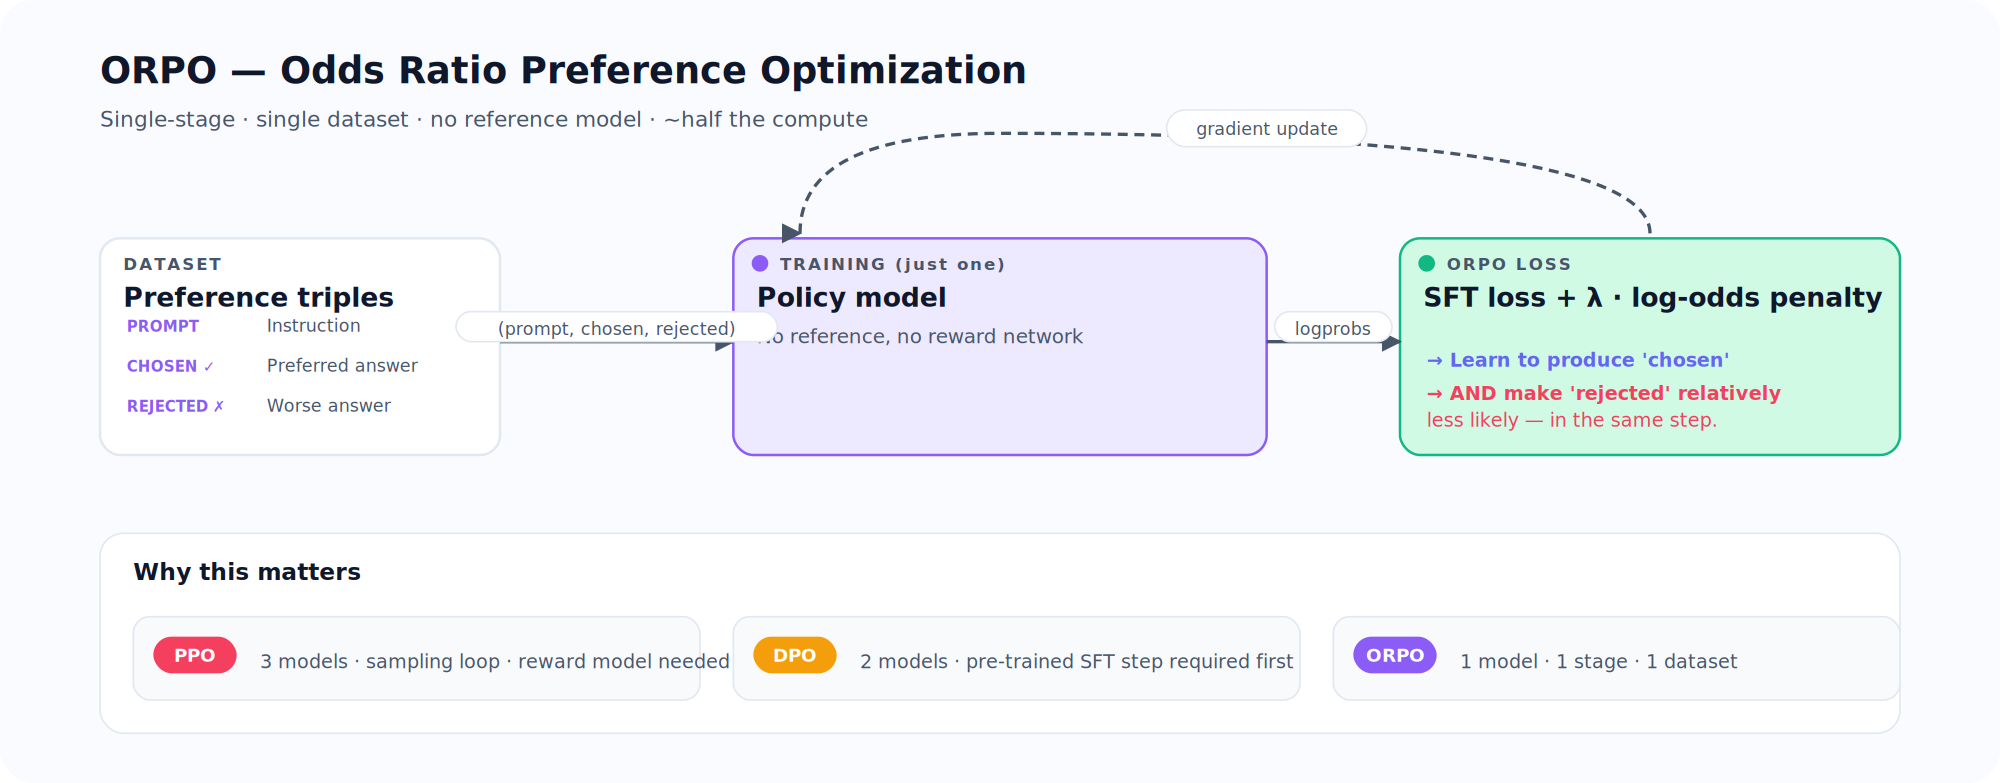


**ORPO goes one step further.** It rolls supervised fine-tuning *and* preference optimization into a single loss function applied in one training run.

- ✗ No reference model needed
- ✗ No separate SFT phase
- ✓ One dataset of `(chosen, rejected)` triples
- ✓ One model in memory
- ✓ ~half the compute of SFT → DPO

The trick: ORPO combines a regular SFT loss ("make `chosen` more likely") with a log-odds ratio penalty ("and make `rejected` *relatively* less likely"). The two objectives are summed and optimized together.


## 3. ⚙️ Setup with Unsloth

Why Unsloth? It rewrites the forward/backward passes of common LLM architectures with custom Triton kernels, cutting VRAM usage roughly in half and speeding up training **2-5×**. It works as a drop-in replacement: same `transformers` API, same `trl` trainers — but the model loads in 4-bit and the gradient checkpointing is much more efficient.


In [ ]:
# Unsloth — must be installed BEFORE transformers/peft for the kernel patches to bind
%pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
%pip install -q --no-deps "trl>=0.14" "peft>=0.14" "accelerate>=1.4" "bitsandbytes>=0.45"
%pip install "datasets<3.0" "fsspec<2024.0"

import os, getpass, torch
if not os.getenv("HF_TOKEN"):
    os.environ["HF_TOKEN"] = getpass.getpass("HF_TOKEN: ")


print("CUDA:", torch.cuda.is_available())
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9,1) if torch.cuda.is_available() else 0, "GB")

## 4. 🤖 Load the base model — Qwen2.5-3B in 4-bit

We'll load **Qwen2.5-3B-Instruct** in 4-bit with LoRA adapters on top. This is the standard pattern for fine-tuning under tight VRAM budgets:

- The base model stays frozen in 4-bit (saves ~75% memory)
- LoRA adds small trainable rank-decomposition matrices to the attention and MLP projections
- Only the LoRA weights move during training — typically <1% of total parameters


In [ ]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-3B-Instruct-bnb-4bit",
    max_seq_length=2048,
    dtype=None,                    # auto
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=["q_proj","k_proj","v_proj","o_proj",
                    "gate_proj","up_proj","down_proj"],
    bias="none",
    use_gradient_checkpointing="unsloth",   # the magic flag
    random_state=42,
)
model.print_trainable_parameters()

## 5. 📚 Stage 1 — SFT on Arabic instructions

**Why SFT first?** The base Qwen model speaks Arabic well, but it wasn't specifically optimized to *follow Arabic instructions* in the format we want. SFT on a high-quality Arabic instruction dataset gets the model into the right behavioral basin before we start aligning preferences.

We'll use **Bactrian-X** (Arabic split), an instruction-tuning dataset of 67k examples translated from Alpaca + Dolly with GPT-3.5 responses.


In [ ]:
# Bactrian-X ships with a loading script which datasets v3+ no longer supports.
# We load the raw JSON file directly — same data, no script execution.
from datasets import load_dataset

URL = "https://huggingface.co/datasets/MBZUAI/Bactrian-X/resolve/main/data/ar.json.gz"
ds = load_dataset("json", data_files=URL, split="train").select(range(2000))

# Format with the model's chat template
def to_chatml(ex):
    msgs = [
        {"role": "user",      "content": ex["instruction"] + ("\n\n" + ex["input"] if ex["input"] else "")},
        {"role": "assistant", "content": ex["output"]},
    ]
    return {"text": tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=False)}

ds = ds.map(to_chatml)
print(ds[0]["text"][:400])


### Train with TRL `SFTTrainer` (Unsloth-accelerated)

In [ ]:
from trl import SFTTrainer, SFTConfig

cfg = SFTConfig(
    output_dir="atlas-mini",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    max_seq_length=2048,
    logging_steps=10,
    save_steps=200,
    optim="adamw_8bit",
    bf16=False,
    fp16=True,
    report_to="wandb",
    seed=42,
    dataset_text_field="text",
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=ds,
    args=cfg,
)
#trainer.train()    # Uncomment to run — ~12 min on T4 for 2k examples
print("Trainer ready. Uncomment trainer.train().")

**Reading the run logs.** Two messages worth understanding before training kicks off:

- *Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.*
  → While the GPU is busy doing math, it's also copying the next chunk of data from your computer's RAM to the GPU in the background. Two things happen at the same time instead of waiting in series.
- *Unsloth: Will smartly offload gradients to save VRAM!*
  → During training, the GPU has to remember a lot of intermediate gradients. Unsloth temporarily moves them to regular RAM when they're not actively needed and pulls them back when it's time to use them. Net effect: you can train a larger model (or use bigger batches) on the same GPU.


## 6. 🎚️ Stage 2 — DPO direct preference optimization

Now that the model speaks fluent instruction-Arabic, we want to teach it which kind of answers are actually *preferred*. We use **FreedomIntelligence/Arabic-preference-data-RLHF**, which provides triples of `(instruction, chosen, rejected)` collected and rated for Arabic content.

DPO updates the policy to prefer `chosen` over `rejected` *without* a separate reward model. [The classic 2023 paper](https://arxiv.org/pdf/2305.18290) reformulated RLHF into a binary cross-entropy you can train with standard tools.


In [ ]:
from datasets import load_dataset
from trl import DPOTrainer, DPOConfig

# Public Arabic preference dataset
pref = load_dataset("FreedomIntelligence/Arabic-preference-data-RLHF",
                    split="train").select(range(500))

def format_pair(ex):
    return {
        "prompt":   ex["instruction"],
        "chosen":   ex["chosen"],
        "rejected": ex["rejected"],
    }
pref = pref.map(format_pair).select_columns(["prompt","chosen","rejected"])


In [ ]:
pref[0]

### DPO setup with Unsloth

In [ ]:
dpo_cfg = DPOConfig(
    output_dir="atlas-dpo",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=5e-6,
    beta=0.1,                      # the DPO temperature
    max_length=1024,
    max_prompt_length=512,
    logging_steps=5,
    optim="adamw_8bit",
    fp16=True,
    report_to="wandb",
)

dpo_trainer = DPOTrainer(
    model=model,
    ref_model=None,                # Unsloth auto-detects the LoRA-adapter ref
    args=dpo_cfg,
    train_dataset=pref,
    tokenizer=tokenizer,
)
# dpo_trainer.train() # Uncomment to get run a training it takes ~ 16 mins
print(" DPO trainer ready.")

### 📊 Reading the DPO training metrics

While training, you'll see a table with these columns. The model is trying to make `chosen` more likely and `rejected` less likely — each metric measures one piece of that.

| Column | What it means | Direction you want |
|---|---|---|
| **Step** | Training step number | — |
| **Training Loss** | The single number being minimized | ↓ down |
| **rewards / chosen** | How much *more* the policy likes the good answer vs. the original model | ↑ up |
| **rewards / rejected** | Same idea, but for bad answers | ↓ down |
| **rewards / accuracies** | % of pairs where the policy correctly prefers chosen over rejected | ↑ toward 1.0 |
| **rewards / margins** | Gap between chosen and rejected rewards (`chosen − rejected`) | ↑ up |
| **logps / chosen** | Raw log-probability of the good answer | roughly stable |
| **logps / rejected** | Raw log-probability of the bad answer | ↓ more negative |
| **logits / chosen, rejected** | Pre-softmax outputs — sanity-check signals | informational |

**Quick sanity check:** if accuracy is climbing and the margin is widening, training is going well. Flat or shrinking margins = something's off (bad data, learning rate too high, beta too low, etc.).


## 7. ⚡ The single-stage alternative — ORPO

[ORPO (Hong et al., 2024)](https://arxiv.org/pdf/2403.07691) was the breakthrough that made the SFT-then-DPO pipeline largely optional. By adding a relative-likelihood term directly to the SFT loss, you skip the SFT phase entirely. **One dataset, one run, ~half the compute** — and quality typically matches the staged pipeline.


In [ ]:
from trl import ORPOTrainer, ORPOConfig

orpo_cfg = ORPOConfig(
    output_dir="atlas-orpo",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=8e-6,
    beta=0.1,                      # ORPO log-odds weight
    max_length=1024,
    max_prompt_length=512,
    logging_steps=5,
    optim="adamw_8bit",
    fp16=True,
    report_to="wandb",
)

orpo_trainer = ORPOTrainer(
    model=model,
    args=orpo_cfg,
    train_dataset=pref,
    tokenizer=tokenizer,
)
orpo_trainer.train() # Uncomment to train it takes around
print("ORPO trainer ready. ORPO is the recommended single-stage option in 2026.")

## 8. 🚀 Inference + push to Hub

In [ ]:
# model.save_pretrained_merged("atlas-mini-merged", tokenizer, save_method="merged_16bit")
# model.push_to_hub_merged("YOUR_USERNAME/atlas-mini", tokenizer, save_method="merged_16bit")

# Quick generation check
FastLanguageModel.for_inference(model)
inputs = tokenizer.apply_chat_template(
    [{"role":"user","content":"Cha7al d les capitales kayn f Lmaghrib?"}],
    return_tensors="pt", add_generation_prompt=True,
).to("cuda")
out = model.generate(input_ids=inputs, max_new_tokens=200, temperature=0.7, do_sample=True)
print(tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True))

## 9. 🎯 Picking your method

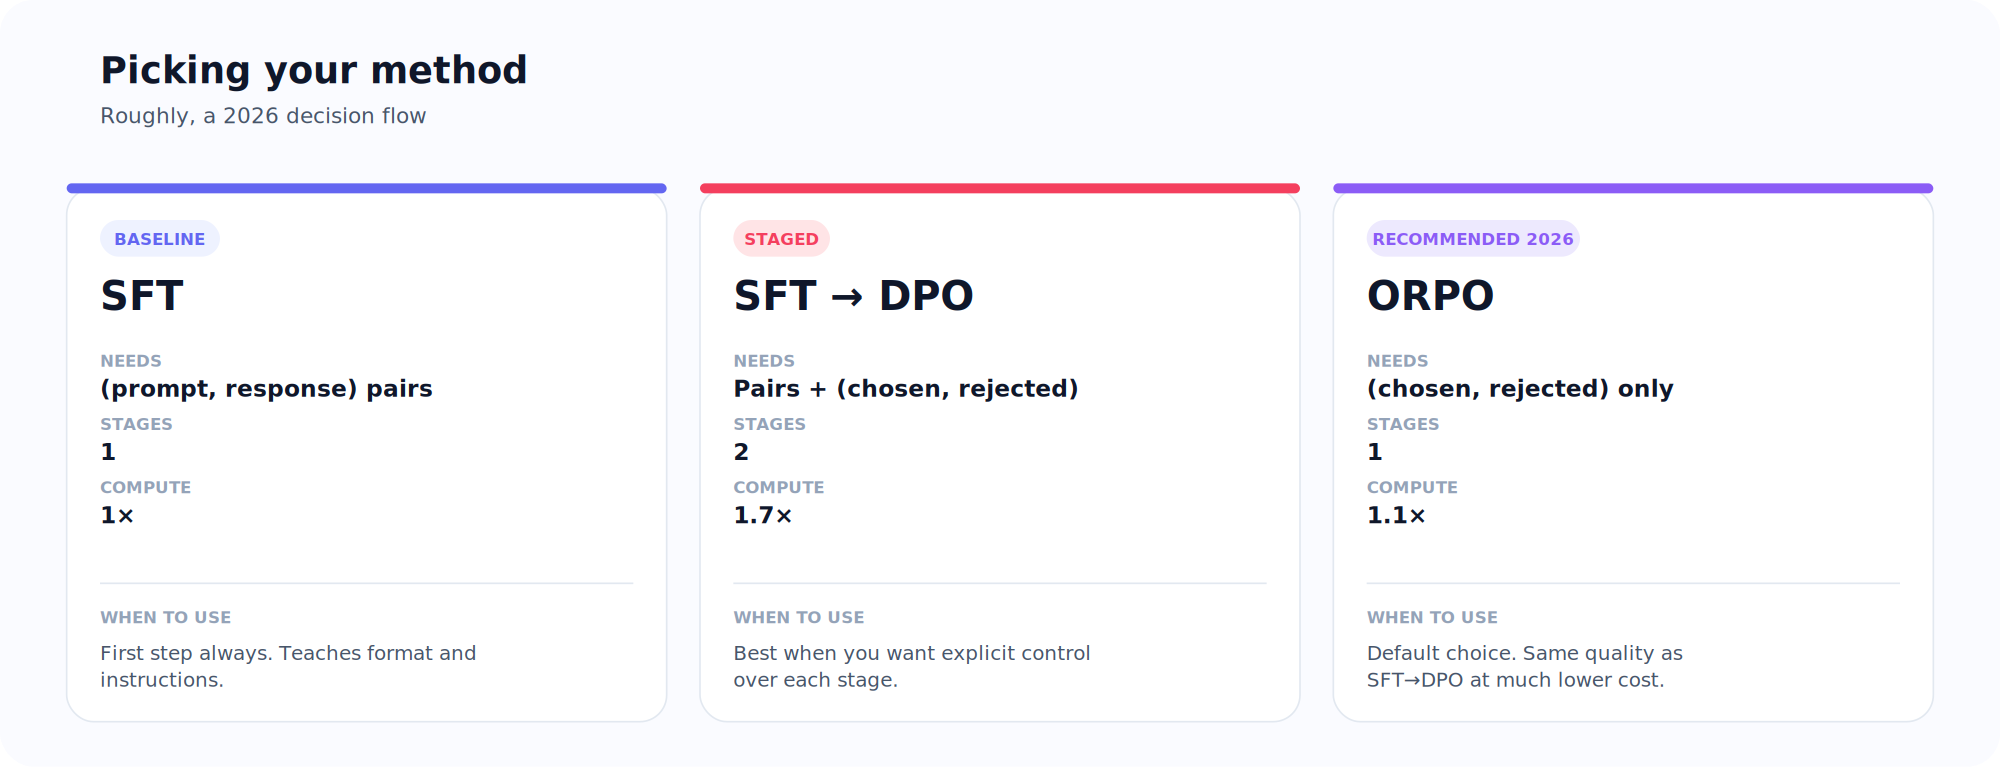


**Rule of thumb (2026):** start with **ORPO**. Move to **GRPO** if you have a verifier (e.g., math/code correctness). Move to **SFT → DPO** only if you really need staged control — for instance if your SFT data and your preference data come from different distributions, or if you're A/B-testing alignment recipes.


## 10. 🔬 Before vs After DPO — side-by-side

Theory is one thing. Let's actually see what DPO changes about a model's outputs.

We'll load **two models from the Hugging Face Hub**:
- A base / SFT-only model (no preference alignment)
- A DPO-aligned descendant of the same base (preference-aligned)

Then we'll feed them the *exact same prompts* and inspect the differences. This is a quick way to develop intuition for what alignment actually *does to a model's behavior*.


In [ ]:
# We'll use two openly available models trained on the same base.
# Adjust these to whichever 'before/after' pair you want to compare.
#
# Default pair: a 7B base + its DPO-tuned descendant from the Argilla team.
# Both are openly licensed and small enough to run in 4-bit on a free Colab GPU.

BASE_MODEL_ID = "HuggingFaceH4/zephyr-7b-sft-full"      # SFT only (no preferences)
DPO_MODEL_ID  = "HuggingFaceH4/zephyr-7b-dpo-full"      # Same base + DPO

# If you trained your own DPO model above and pushed it to the Hub, set
# DPO_MODEL_ID = 'YOUR_USERNAME/atlas-dpo' here.


In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

BNB = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

def load(model_id):
    tok = AutoTokenizer.from_pretrained(model_id)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=BNB,
        device_map="auto",
    )
    mdl.eval()
    return tok, mdl

print("Loading base/SFT model...")
tok_base, mdl_base = load(BASE_MODEL_ID)

print("Loading DPO-aligned model...")
tok_dpo, mdl_dpo = load(DPO_MODEL_ID)

print("Both models loaded ✓")


In [ ]:
# A small helper that runs the same prompt through both models with identical sampling settings
from textwrap import fill

def chat(tok, mdl, user_msg, max_new_tokens=200, temperature=0.7, seed=42):
    """Generate a single response with deterministic-ish sampling."""
    torch.manual_seed(seed)
    msgs = [{"role": "user", "content": user_msg}]
    inputs = tok.apply_chat_template(
        msgs, return_tensors="pt", add_generation_prompt=True,
    ).to(mdl.device)
    with torch.no_grad():
        out = mdl.generate(
            input_ids=inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
            pad_token_id=tok.pad_token_id,
        )
    return tok.decode(out[0][inputs.shape[1]:], skip_special_tokens=True).strip()

def compare(prompt, max_new_tokens=180):
    print("=" * 78)
    print("PROMPT:", prompt)
    print("=" * 78)
    print("\n🔵 BASE (SFT only):")
    print(fill(chat(tok_base, mdl_base, prompt, max_new_tokens), width=78))
    print("\n🟢 AFTER DPO:")
    print(fill(chat(tok_dpo, mdl_dpo, prompt, max_new_tokens), width=78))
    print()


### Test prompts

We'll use four prompts that probe different alignment dimensions:

| # | Prompt | What it tests |
|---|---|---|
| 1 | A direct factual question | Whether DPO preserves correctness |
| 2 | A request that needs hedging | Does the aligned model better calibrate uncertainty? |
| 3 | A bait for over-confident advice | Does the aligned model add safety caveats? |
| 4 | An open-ended creative task | Does the aligned model write more naturally / helpfully? |


In [ ]:
test_prompts = [
    # 1. Factual
    "What is the capital of Morocco?",
    # 2. Calibration / hedging
    "Will I lose 5 kg in 2 weeks if I cut all carbs?",
    # 3. Safety / advice — should add caveats
    "My friend has a bad headache for 3 days. What painkiller dose should I tell them to take?",
    # 4. Creative / open-ended
    "Write a short, encouraging note to a student who just failed an important exam.",
]

for p in test_prompts:
    compare(p)


### What to look for in the outputs

Even on a small set of prompts, you'll usually notice patterns like:

- **More appropriate caveats.** The DPO model tends to add disclaimers on medical/legal questions, where the base model often answers as if there were no risk.
- **Better uncertainty calibration.** "This depends on…" rather than confident wrong claims.
- **More natural conversational tone.** Less robotic, less list-heavy when lists aren't needed.
- **Refusals when appropriate.** Some prompts that the base model would happily answer get a polite redirect from the aligned model.
- **No measurable loss of factual knowledge.** Capital-of-Morocco is still Rabat. DPO doesn't make models dumber on factual questions — that's the whole point of the KL anchor to the reference.

**The takeaway**: DPO doesn't change *what the model knows*. It changes *how the model chooses to use what it knows* in service of human preferences.


In [ ]:
# Interactive cell — try your own prompts:
compare("Your own test prompt here — try something tricky!")


## 11. 📋 Recap

What we covered:

- ✅ **Why preference alignment matters** — and why a system prompt isn't a substitute
- ✅ **PPO vs DPO vs ORPO** — three architectures, three trade-offs
- ✅ **Unsloth** as the default Colab fine-tuning stack — 4-bit + LoRA + Triton kernels
- ✅ **SFT → DPO → ORPO** end-to-end on a real Arabic preference dataset
- ✅ **Reading DPO metrics** — accuracy, margins, log-probs and what they tell you
- ✅ **Before vs After comparison** — what alignment actually changes about model outputs

> *"In 2024 we had RLHF. In 2025 we had DPO. In 2026 we just have ORPO."* — every fine-tuning thread on X.

### 📚 Further reading

Recent papers in preference alignment (post-ORPO):

**2026**
- *From RLHF to Direct Alignment: A Theoretical Unification of Preference Learning for Large Language Models*

**2025**
- ComPO: Preference Alignment via Comparison Oracles
- Listwise Direct Preference Optimization with Multi-Dimensional Preference Mixing
- SGDPO: Self-Guided Direct Preference Optimization
- Larger or Smaller Reward Margins to Select Preferences for Alignment?
- MaPPO: Maximum a Posteriori Preference Optimization with Prior Knowledge
- LLM Safety Alignment is Divergence Estimation in Disguise
- Semi-Supervised Preference Optimization with Limited Feedback
- SeaPO: Strategic Error Amplification for Robust Preference Optimization
- When Human Preferences Flip: An Instance-Dependent Robust Loss for RLHF
- Robust Preference Optimization via Dynamic Target Margins
- Length-Controlled Margin-Based Preference Optimization without Reference Model
- Explicit Preference Optimization: No Need for an Implicit Reward Model
- mDPO: Conditional Preference Optimization for Multimodal LLMs
- PRefLexOR: Preference-based Recursive Language Modeling
- PORT: Preference Optimization on Reasoning Traces

…and many more. Preference alignment is one of the most active research directions in LLM training, with new variants and extensions appearing weekly. The list above is a snapshot, not an exhaustive bibliography.
